In [8]:
# ---------------- IMPORTS ---------------- #
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [10]:
# ---------------- LOAD DATA ---------------- #
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake["label"] = 0
true["label"] = 1

data = pd.concat([fake, true])
data = data.sample(frac=1).reset_index(drop=True)

In [11]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

data["text"] = data["text"].apply(clean_text)

In [12]:
X = data["text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [14]:
# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

# SVM
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

LinearSVC()

In [15]:
nb_preds = nb.predict(X_test_tfidf)
lr_preds = lr.predict(X_test_tfidf)
svm_preds = svm.predict(X_test_tfidf)

In [17]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_preds))
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))
print("SVM Accuracy:", accuracy_score(y_test, svm_preds))

Naive Bayes Accuracy: 0.9518930957683742
Logistic Regression Accuracy: 0.9906458797327394
SVM Accuracy: 0.9968819599109131


In [18]:
print("\nNaive Bayes Report:\n", classification_report(y_test, nb_preds))
print("\nLogistic Regression Report:\n", classification_report(y_test, lr_preds))
print("\nSVM Report:\n", classification_report(y_test, svm_preds))


Naive Bayes Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.95      4679
           1       0.95      0.95      0.95      4301

    accuracy                           0.95      8980
   macro avg       0.95      0.95      0.95      8980
weighted avg       0.95      0.95      0.95      8980


Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      4679
           1       0.99      0.99      0.99      4301

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


SVM Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4679
           1       1.00      1.00      1.00      4301

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted

In [19]:
cm_nb = confusion_matrix(y_test, nb_preds)
cm_lr = confusion_matrix(y_test, lr_preds)
cm_svm = confusion_matrix(y_test, svm_preds)

In [20]:
print("\nNaive Bayes Confusion Matrix:\n", cm_nb)
print("\nLogistic Regression Confusion Matrix:\n", cm_lr)
print("\nSVM Confusion Matrix:\n", cm_svm)


Naive Bayes Confusion Matrix:
 [[4453  226]
 [ 206 4095]]

Logistic Regression Confusion Matrix:
 [[4625   54]
 [  30 4271]]

SVM Confusion Matrix:
 [[4670    9]
 [  19 4282]]


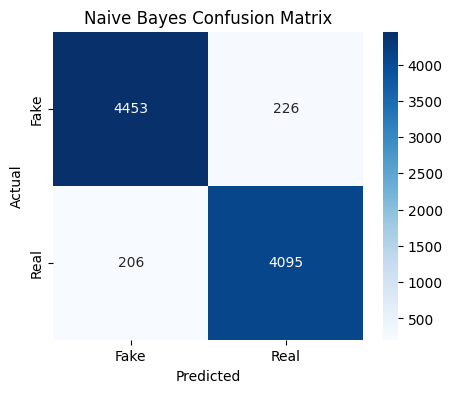

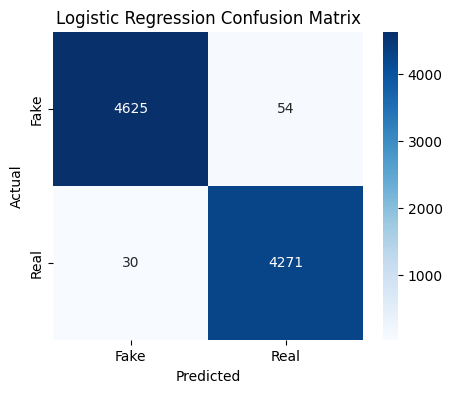

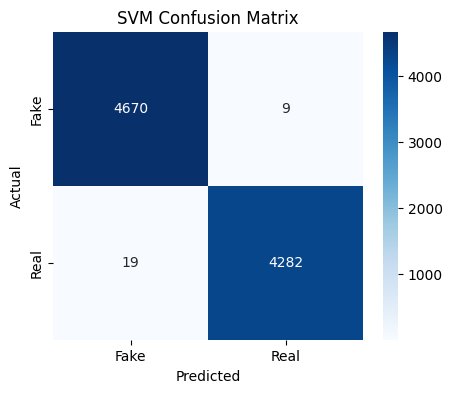

In [21]:
models = {
    "Naive Bayes": cm_nb,
    "Logistic Regression": cm_lr,
    "SVM": cm_svm
}

for name, cm in models.items():
    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Fake", "Real"],
        yticklabels=["Fake", "Real"]
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [ ]:
pickle.dump(nb, open("nb_model.pkl", "wb"))
pickle.dump(lr, open("lr_model.pkl", "wb"))
pickle.dump(svm, open("svm_model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))

In [ ]:
# ---------------- DOWNLOAD FILES ---------------- #
files.download("nb_model.pkl")
files.download("lr_model.pkl")
files.download("svm_model.pkl")
files.download("tfidf_vectorizer.pkl")